In [1]:
# =====================
# Test Environment Setup
# =====================


# Model will download automatically into Ultralytic cache
# model = YOLO("yolov8n.pt") 

In [2]:
# ===================
# Test the Setup Model
# ===================
# import numpy as np

# img = np.zeros((640, 640, 3), dtype=np.uint8)
# results = model(img)
# results

In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
# from ultralytics import YOLO

# class YOLODetector:
#     def __init__(self, model_path: str):
#         self.model = YOLO(model_path)

#     def predict(self, frame):
#         results = self.model.predict(
#             frame,
#             verbose=False,
#             conf=0.35
#         )
#         return results[0]

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

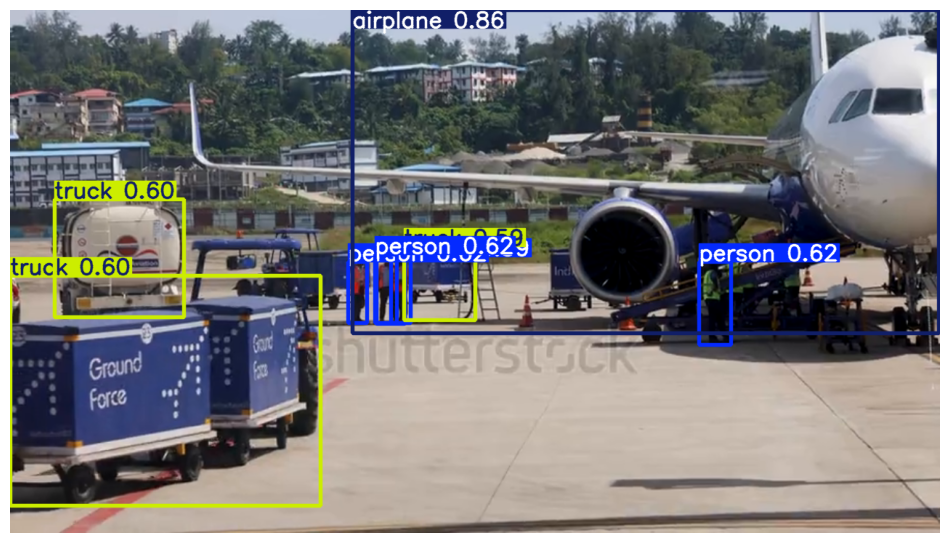

In [5]:
# =======================
# Test Inference Scripts
# =======================
import sys
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.getcwd()).parent
# Connect to custom-defined modules
sys.path.append(str(PROJECT_ROOT))

from airport_ai.streams.camera import AsyncCamera
from airport_ai.inference.detector import YOLODetector
from airport_ai.inference.parser import DetectionParser
from airport_ai.config.settings import *

camera = AsyncCamera(
    source=VIDEO_SOURCE,
    width=FRAME_WIDTH,
    height=FRAME_HEIGHT,
    queue_size=FRAME_QUEUE_SIZE,
).start()

detector = YOLODetector(str(PROJECT_ROOT/"models/yolov8n.pt"))
detector_parser = DetectionParser()

""" Window Not Opening"""
# while True:
#     frame = camera.read()
#     result = detector.predict(frame)
#     detections = parser.parse(result)
#     annotated = result.plot()
#     cv2.imshow("YOLO Detection", annotated)
#     print("-"*40)
#     for detection in detections:
#         print(detection)
#     if cv2.waitKey(1) == ord("q"):
#         break
# camera.stop()
# cv2.destroyAllWindows()

frame = camera.read()
detector_result = detector.predict(frame)
detections = detector_parser.parse(detector_result)
detector_annotated = detector_result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(detector_annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")


In [6]:
for detection in detections:
    print(detection)

Detection(class_id=4, class_name='airplane', confidence=0.8629162311553955, x1=471.3492431640625, y1=1.063018798828125, x2=1278.03955078125, y2=445.39129638671875, center_x=874.6943969726562, center_y=223.22715759277344, width=806.6903076171875, height=444.3282775878906)
Detection(class_id=0, class_name='person', confidence=0.6234205961227417, x1=502.2510986328125, y1=337.89398193359375, x2=532.9761962890625, y2=431.58380126953125, center_x=517.6136474609375, center_y=384.7388916015625, width=30.72509765625, height=93.6898193359375)
Detection(class_id=0, class_name='person', confidence=0.62135910987854, x1=948.974853515625, y1=347.9691162109375, x2=992.548828125, y2=461.59222412109375, center_x=970.7618408203125, center_y=404.7806701660156, width=43.573974609375, height=113.62310791015625)
Detection(class_id=0, class_name='person', confidence=0.6183834671974182, x1=465.15032958984375, y1=347.4193115234375, x2=491.43499755859375, y2=431.8294677734375, center_x=478.29266357421875, center

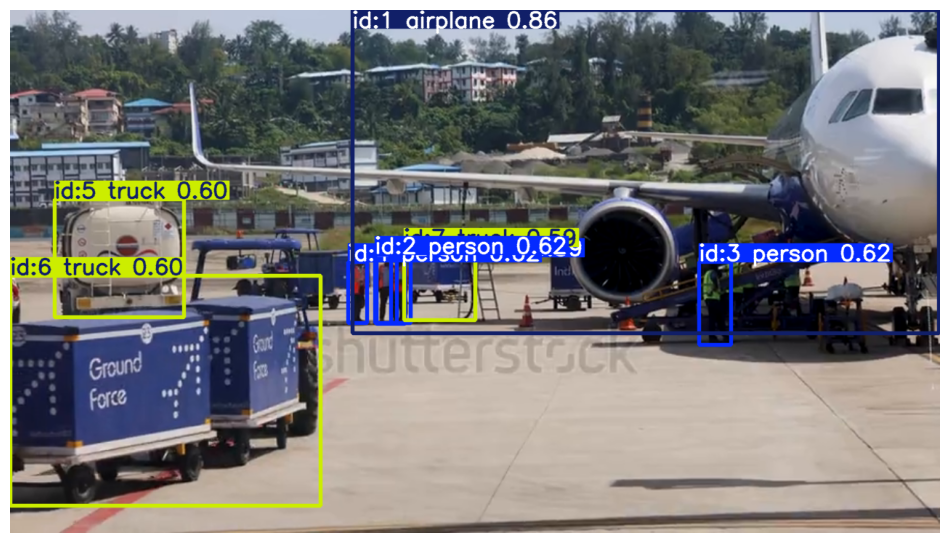

In [7]:
# ==========================
# Test Object Tracking
# ==========================
from airport_ai.tracking.tracker import YOLOTracker
from airport_ai.tracking.parser import TrackingParser

tracker = YOLOTracker(str(PROJECT_ROOT/"models/yolov8n.pt"))
tracker_parser = TrackingParser()

tracker_result = tracker.track(frame)
tracked_objects = tracker_parser.parse(tracker_result)
tracker_annotated = tracker_result.plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(tracker_annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [8]:
for obj in tracked_objects:
    print(obj)

TrackedObject(track_id=1, class_id=4, class_name='airplane', confidence=0.8629162311553955, x1=471.3492431640625, y1=1.063018798828125, x2=1278.03955078125, y2=445.39129638671875, center_x=874.6943969726562, center_y=223.22715759277344, width=806.6903076171875, height=444.3282775878906)
TrackedObject(track_id=2, class_id=0, class_name='person', confidence=0.6234205961227417, x1=502.2510986328125, y1=337.89398193359375, x2=532.9761962890625, y2=431.58380126953125, center_x=517.6136474609375, center_y=384.7388916015625, width=30.72509765625, height=93.6898193359375)
TrackedObject(track_id=3, class_id=0, class_name='person', confidence=0.62135910987854, x1=948.974853515625, y1=347.9691162109375, x2=992.548828125, y2=461.59222412109375, center_x=970.7618408203125, center_y=404.7806701660156, width=43.573974609375, height=113.62310791015625)
TrackedObject(track_id=4, class_id=0, class_name='person', confidence=0.6183834671974182, x1=465.15032958984375, y1=347.4193115234375, x2=491.434997558

In [9]:
# ==============================
# Turnaround Pipeline
# ==============================
# 1. Aircraft Selection
from airport_ai.decision.turnaround.aircraft import AircraftSelector

selector = AircraftSelector()
aircraft = selector.select(tracked_objects)

print(aircraft)

TrackedObject(track_id=1, class_id=4, class_name='airplane', confidence=0.8629162311553955, x1=471.3492431640625, y1=1.063018798828125, x2=1278.03955078125, y2=445.39129638671875, center_x=874.6943969726562, center_y=223.22715759277344, width=806.6903076171875, height=444.3282775878906)


In [10]:
# 2. Safety Zone & Evaluator
from airport_ai.decision.turnaround.zone import SafetyZoneGenerator
from airport_ai.decision.turnaround.evaluator import TurnaroundEvaluator

if aircraft is not None:
    generator = SafetyZoneGenerator(
        margin_x=ZONE_MARGIN_X,
        margin_y=ZONE_MARGIN_Y
    )
    safety_zone = generator.generate(aircraft)
    evaluator = TurnaroundEvaluator()
    events = evaluator.evaluate(tracked_objects, safety_zone)

for event in events:
    print(event.event_type)
    print(event.message)


Safety Zone Violation
Person 2 entered aircraft safety zone.
Safety Zone Violation
Person 3 entered aircraft safety zone.
Safety Zone Violation
Person 4 entered aircraft safety zone.
Vehicle Zone Violation
Vehicle 7 entered aircraft safety zone.
Safety Zone Violation
Person 8 entered aircraft safety zone.
Safety Zone Violation
Person 9 entered aircraft safety zone.


In [11]:
# 3. Test Visualizer
from airport_ai.decision.turnaround.visualization import TurnaroundVisualizer
visualizer = TurnaroundVisualizer()
frame = visualizer.draw_zone(frame, safety_zone)

In [20]:
# ======================
# Test Storage Script
# ======================
from airport_ai.config.settings import DATABASE_PATH
from airport_ai.storage.database import Database
from airport_ai.storage.schema import DatabaseSchema
from airport_ai.storage.repository import EventRepository

database = Database(DATABASE_PATH)
DatabaseSchema(database).create_tables()
repository = EventRepository(database)

repository.save("TURNAROUND", event)
rows = repository.get_recent()
for row in rows:
    print(row)

('2026-07-28T03:51:49.436271', 'TURNAROUND', 2, 'person', 'Safety Zone Violation', 'HIGH', 'Person 2 entered aircraft safety zone.')
